In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import random

## Dependencies
  - python=3.12
  - pytorch
  - torchvision
  - torchaudio
  - pytorch-cuda=11.8
  - jupyter
  - scikit-learn
  - matplotlib
  - seaborn
  - pillow
  - numpy

## Hardware specifications

In [2]:
!nvidia-smi

Thu May  8 06:02:24 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.28                 Driver Version: 576.28         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   56C    P4             10W /   86W |     577MiB /   6141MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# --- DEVICE ---
if torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple M1/M2/M3/M4 GPU
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


## For Reproducibility


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Preprocessing helmet image dataset
Removing the exact same images from the dataset we collected to prevent overfitting.

In [4]:
# import os
# import hashlib

# def remove_exact_duplicates(folder_path):
#     seen = set()
#     removed = 0

#     for subdir, _, files in os.walk(folder_path):
#         for file in files:
#             path = os.path.join(subdir, file)
#             try:
#                 with open(path, 'rb') as f:
#                     file_hash = hashlib.md5(f.read()).hexdigest()
#                 if file_hash in seen:
#                     os.remove(path)
#                     removed += 1
#                 else:
#                     seen.add(file_hash)
#             except Exception as e:
#                 print(f"Error processing {path}: {e}")

#     print(f"Removed {removed} exact duplicate image(s).")

# remove_exact_duplicates("helmet_dataset")


In [4]:
# --- SETTINGS ---
dataset_path = "helmet_dataset"
image_size = 224
print(os.listdir("helmet_dataset"))

['.DS_Store', 'looking', 'not_looking']


In [25]:
# --- SAFETY LOADER ---
def pil_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

In [26]:
# --- TRANSFORM ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),              # Resize slightly bigger
    transforms.RandomHorizontalFlip(p=0.5),     # Good if left/right isn’t label-dependent
    transforms.RandomRotation(10),              # Small tilt variation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),             
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


**Resizing** - Is done to ensure consistent input dimensions for the CNN. This also reduces computational load.

**RandomHorizontalFlip** - This simulates real-world variations and helps the model generalize better. Also, since  orientation doesn't affect the label. 

**Random Rotation** - This makes the model more robust to viewpoint changes in real-world usage.

**Normalization** - We used normalization based on ImageNet stats, which is a common best practice in deep learning. Even though our model wasn't pretrained on ImageNet. However, this centers the input distributions and improves training convergence.

**ToTensor()** - So that the images are compatible with PyTorch

For the **Validation Set** we do not apply augmentation but just resizing and normalization for consistent evaluation without any artifical modifications.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


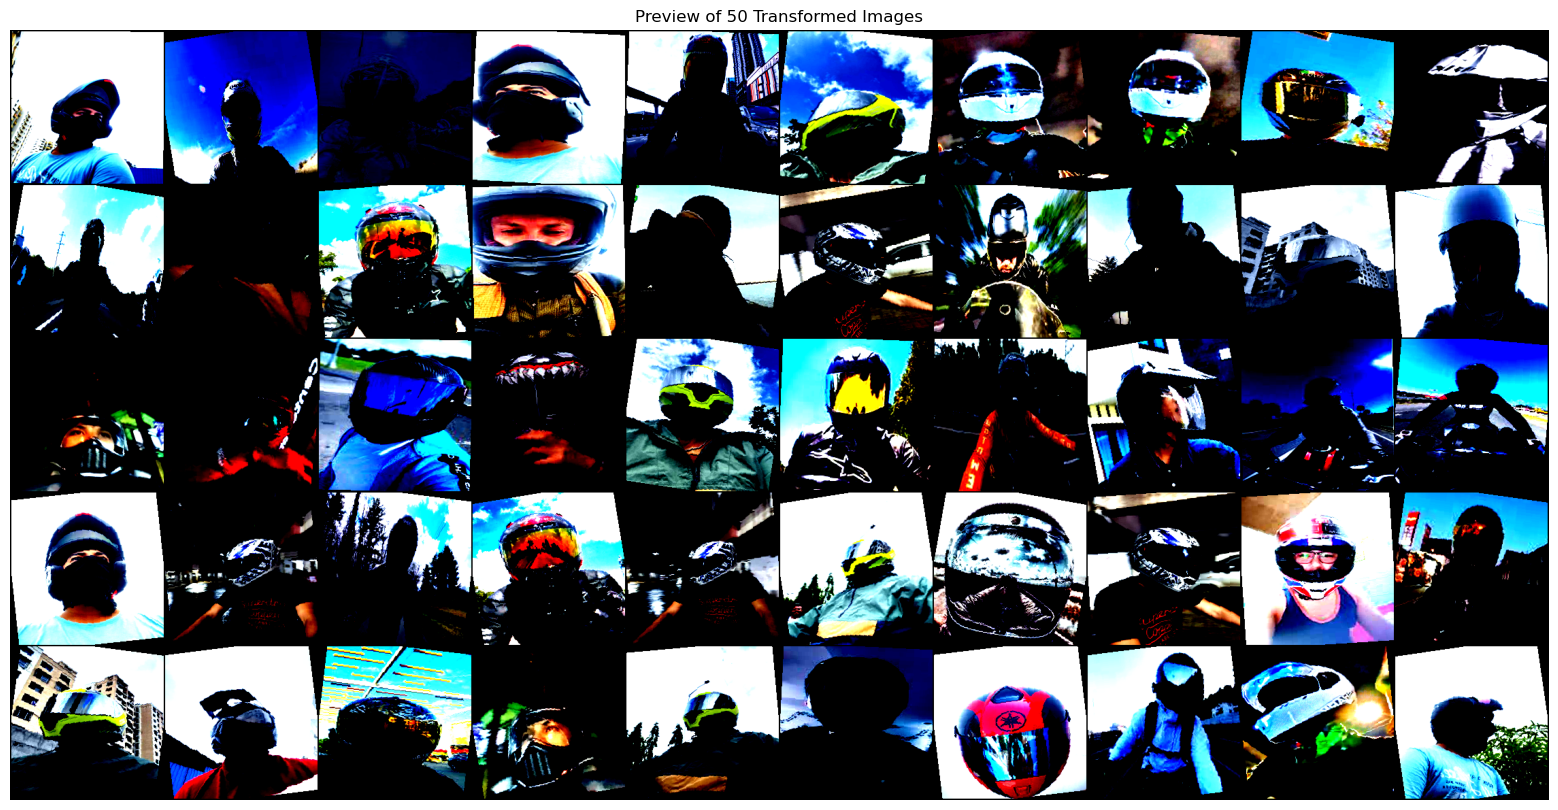

In [27]:
import torchvision

# Load dataset with transform applied
preview_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform,
    loader=pil_loader
)

# Create a DataLoader (no shuffling)
preview_loader = DataLoader(preview_dataset, batch_size=50, shuffle=True)

# Get one batch
images, labels = next(iter(preview_loader))

# Make a grid of 50 images (5 rows × 10 columns)
grid_img = torchvision.utils.make_grid(images[:50], nrow=10, padding=2)

# Unnormalize if needed (for display only)
np_img = grid_img.permute(1, 2, 0).numpy()

# Show the image grid
plt.figure(figsize=(20, 10))
plt.imshow(np_img)
plt.axis('off')
plt.title("Preview of 50 Transformed Images")
plt.show()

## Preparing Dataset

In [28]:
import shutil

# Delete any .ipynb_checkpoints inside helmet_dataset
checkpoints_path = os.path.join(dataset_path, ".ipynb_checkpoints")
if os.path.exists(checkpoints_path):
    shutil.rmtree(checkpoints_path)
    print("Removed .ipynb_checkpoints folder.")

In [29]:
# --- DATASET ---
def is_valid_image(path):
    return not any(x in path for x in ['.DS_Store', '.ipynb_checkpoints'])
    
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None,
    loader=pil_loader,
    is_valid_file=is_valid_image
)

print("Classes:", dataset.classes)
print("Class-to-index:", dataset.class_to_idx)

Classes: ['looking', 'not_looking']
Class-to-index: {'looking': 0, 'not_looking': 1}


In [30]:
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter

# Use full dataset (700 images)
targets = dataset.targets  # From ImageFolder

In [31]:
# Custom wrapper to apply transform after subset
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

## Building 5 Layer CNN Model

In [47]:
import torch.nn.functional as F

class DeeperCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(DeeperCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # 3 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 112x112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 16 -> 32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 56x56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 32 -> 64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 28x28

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 64 -> 128
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 14x14

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 128 -> 256
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 7x7
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # output: 256 x 1 x 1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pool(x)
        x = self.classifier(x)
        return x

## Preparing Smaller Dataset for Fine tuning

In [41]:
subset_size = 300

splitter = StratifiedShuffleSplit(n_splits=1, test_size=(subset_size / len(dataset)), random_state=42)

for small_idx, _ in splitter.split(np.zeros(len(targets)), targets):
    small_dataset = torch.utils.data.Subset(dataset, small_idx)

subset_labels = [dataset.targets[i] for i in small_dataset.indices]
print("Small subset size:", len(small_dataset))
print("Class counts:", Counter(subset_labels))

Small subset size: 404
Class counts: Counter({0: 203, 1: 201})


In [42]:
small_targets = [dataset.targets[i] for i in small_dataset.indices]

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(small_targets)), small_targets):
    train_dataset = torch.utils.data.Subset(small_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(small_dataset, val_idx)

In [43]:
# Apply transforms
train_dataset = TransformedSubset(train_dataset, train_transform)
val_dataset = TransformedSubset(val_dataset, val_transform)

## Fine tuning using Grid Search

In [44]:
from itertools import product
import time

def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
    return model

def evaluate_model(model, val_loader, criterion):
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    avg_loss = total_loss / len(val_loader)
    return accuracy, avg_loss

In [45]:
import gc

param_grid = {
    "batch_size": [16, 32, 64],
    "lr": [1e-3, 5e-4, 1e-4],
    "epochs": [5, 10]
}

all_params = list(product(*param_grid.values()))
param_names = list(param_grid.keys())
results = []

for params in all_params:
    config = dict(zip(param_names, params))
    print(f"\n🔧 Running config: {config}")

    # Set up loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])

    # Initialize model
    model = DeeperCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

    # Training
    start = time.time()
    trained_model = train_model(model, train_loader, criterion, optimizer, epochs=config['epochs'])
    val_acc, val_loss = evaluate_model(trained_model, val_loader, criterion)
    end = time.time()

    print(f"✅ Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f} | Time: {end - start:.2f}s")

    results.append({
        'lr': config['lr'],
        'batch_size': config['batch_size'],
        'epochs': config['epochs'],
        'val_acc': val_acc,
        'val_loss': val_loss,
        'time': end - start
    })

    # Cleanup
    del model
    del trained_model
    torch.cuda.empty_cache()
    gc.collect()


🔧 Running config: {'batch_size': 16, 'lr': 0.001, 'epochs': 5}
✅ Val Acc: 0.6420 | Val Loss: 0.6084 | Time: 35.30s

🔧 Running config: {'batch_size': 16, 'lr': 0.001, 'epochs': 10}
✅ Val Acc: 0.5679 | Val Loss: 0.7297 | Time: 69.70s

🔧 Running config: {'batch_size': 16, 'lr': 0.0005, 'epochs': 5}
✅ Val Acc: 0.6296 | Val Loss: 0.5775 | Time: 35.42s

🔧 Running config: {'batch_size': 16, 'lr': 0.0005, 'epochs': 10}
✅ Val Acc: 0.7160 | Val Loss: 0.5006 | Time: 69.48s

🔧 Running config: {'batch_size': 16, 'lr': 0.0001, 'epochs': 5}
✅ Val Acc: 0.6049 | Val Loss: 0.5799 | Time: 36.83s

🔧 Running config: {'batch_size': 16, 'lr': 0.0001, 'epochs': 10}
✅ Val Acc: 0.6420 | Val Loss: 0.5411 | Time: 72.29s

🔧 Running config: {'batch_size': 32, 'lr': 0.001, 'epochs': 5}
✅ Val Acc: 0.5802 | Val Loss: 1.0641 | Time: 34.58s

🔧 Running config: {'batch_size': 32, 'lr': 0.001, 'epochs': 10}
✅ Val Acc: 0.7778 | Val Loss: 0.6258 | Time: 67.84s

🔧 Running config: {'batch_size': 32, 'lr': 0.0005, 'epochs': 5}

In [46]:
best = max(results, key=lambda x: x['val_acc'])
print(f"\nBest Config: {best}")


Best Config: {'lr': 0.001, 'batch_size': 32, 'epochs': 10, 'val_acc': 0.7777777777777778, 'val_loss': 0.6257931192715963, 'time': 67.8354082107544}


## Training the model with best hyperparameter

Using the whole dataset to train the model with the best hyperparameter.

**Model**: Custom 5-layer CNN

Final Hyperparameters:
* Learning Rate: 0.001
* Batch Size: 32
* Epochs: 15
* Optimizer: Adam
* Loss Function: CrossEntropyLoss

In [73]:
best_config = {
    'lr': 0.0001,
    'batch_size': 32,
    'epochs': 20,
    'patience': 7,
    'weight_decay': 1e-4,
    'optimizer': 'Adam'
}

In [74]:
# Prepare full dataset, dividing into testing and training.
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(targets)), targets):
    train_dataset = torch.utils.data.Subset(dataset, train_idx)
    val_dataset = torch.utils.data.Subset(dataset, val_idx)

print("Train set size:", len(train_dataset))
print("Val set size:", len(val_dataset))

train_labels = [dataset.targets[i] for i in train_dataset.indices]
val_labels = [dataset.targets[i] for i in val_dataset.indices]
print("Train class counts:", Counter(train_labels))
print("Val class counts:", Counter(val_labels))

Train set size: 492
Val set size: 212
Train class counts: Counter({0: 247, 1: 245})
Val class counts: Counter({0: 106, 1: 106})


In [75]:
# Apply transforms
full_train_dataset = TransformedSubset(train_dataset, train_transform)
full_val_dataset = TransformedSubset(val_dataset, val_transform)

In [76]:
train_loader = DataLoader(full_train_dataset, batch_size=best_config['batch_size'], shuffle=True)
val_loader = DataLoader(full_val_dataset, batch_size=best_config['batch_size'], shuffle=False)

In [77]:
model = DeeperCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_config['lr'], weight_decay=best_config['weight_decay'])

In [78]:
# --- METRICS TRACKING ---
train_losses = []
train_accuracies = []
val_accuracies = []
val_losses = []

In [79]:
def trainAndEval(epochs, patience):
    best_val_acc = 0.0
    patience_counter = 0
    best_epoch = 0
    best_model_state = None
    best_preds = []
    best_labels = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                val_loss += criterion(outputs, labels).item() * images.size(0)

        accuracy = 100 * correct / total
        loss = val_loss / len(val_loader.dataset)
        val_losses.append(loss)
        val_accuracies.append(accuracy)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Val Loss: {loss:.4f} - Val Acc: {accuracy:.4f}%")

        # --- Check for best epoch using validation accuracy ---
        if accuracy > best_val_acc:
            best_val_acc = accuracy
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = model.state_dict()
            best_preds = all_preds
            best_labels = all_labels
        else:
            patience_counter += 1
            print(f"⚠️  No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("⏹️ Early stopping triggered.")
                break

    return best_model_state, best_epoch, best_val_acc, best_preds, best_labels

best_model_state, best_epoch, best_val_acc, best_preds, best_labels = trainAndEval(epochs=20, patience=7)

Epoch 1/20 - Train Loss: 0.6940 - Train Acc: 0.5427 - Val Loss: 0.6958 - Val Acc: 50.0000%
Epoch 2/20 - Train Loss: 0.6522 - Train Acc: 0.6423 - Val Loss: 0.6702 - Val Acc: 66.5094%
Epoch 3/20 - Train Loss: 0.6368 - Train Acc: 0.6626 - Val Loss: 0.6344 - Val Acc: 68.8679%
Epoch 4/20 - Train Loss: 0.6158 - Train Acc: 0.7093 - Val Loss: 0.6246 - Val Acc: 63.2075%
⚠️  No improvement. Patience: 1/7
Epoch 5/20 - Train Loss: 0.5997 - Train Acc: 0.6829 - Val Loss: 0.5961 - Val Acc: 69.3396%
Epoch 6/20 - Train Loss: 0.5791 - Train Acc: 0.7276 - Val Loss: 0.6348 - Val Acc: 61.3208%
⚠️  No improvement. Patience: 1/7
Epoch 7/20 - Train Loss: 0.5658 - Train Acc: 0.7276 - Val Loss: 0.5901 - Val Acc: 71.6981%
Epoch 8/20 - Train Loss: 0.5449 - Train Acc: 0.7398 - Val Loss: 0.5636 - Val Acc: 70.7547%
⚠️  No improvement. Patience: 1/7
Epoch 9/20 - Train Loss: 0.5248 - Train Acc: 0.7663 - Val Loss: 0.6082 - Val Acc: 70.7547%
⚠️  No improvement. Patience: 2/7
Epoch 10/20 - Train Loss: 0.5054 - Train Acc:

In [80]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [86]:
print(f"\nBest Epoch: {best_epoch} | Val Accuracy: {best_val_acc:.4f}")


Best Epoch: 18 | Val Accuracy: 78.3019


## Evaluation and Anaylsis

In [92]:
print("\nClassification Report (Best Epoch):")
print(classification_report(best_labels, best_preds, target_names=dataset.classes))


Classification Report (Best Epoch):
              precision    recall  f1-score   support

     looking       0.73      0.89      0.80       106
 not_looking       0.86      0.68      0.76       106

    accuracy                           0.78       212
   macro avg       0.80      0.78      0.78       212
weighted avg       0.80      0.78      0.78       212



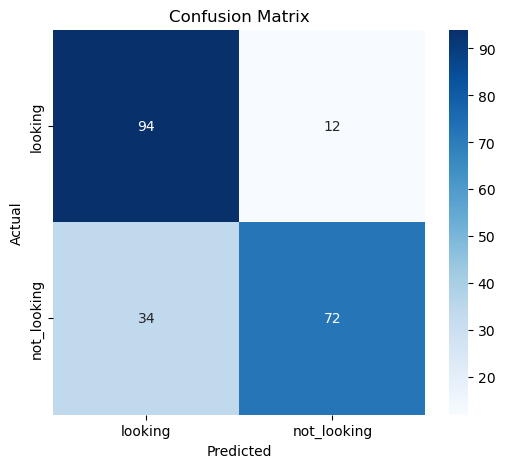

In [93]:
# --- CONFUSION MATRIX ---
cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

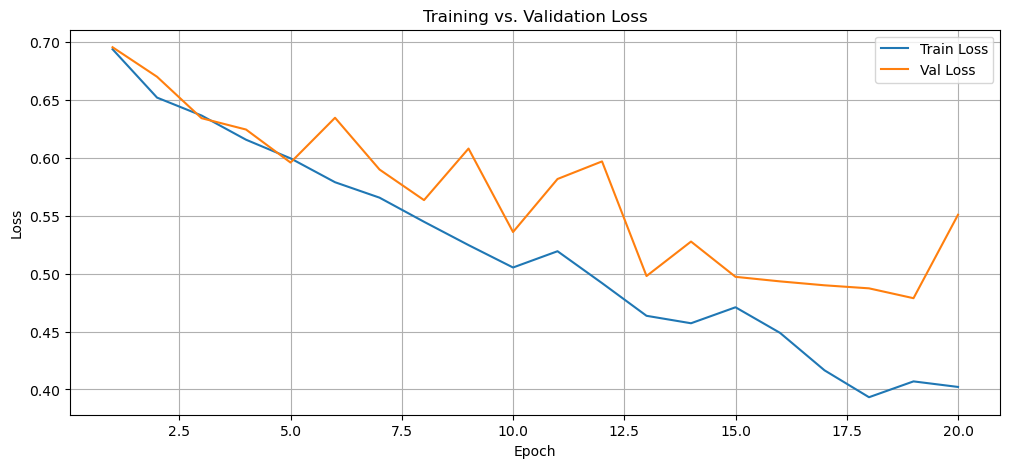

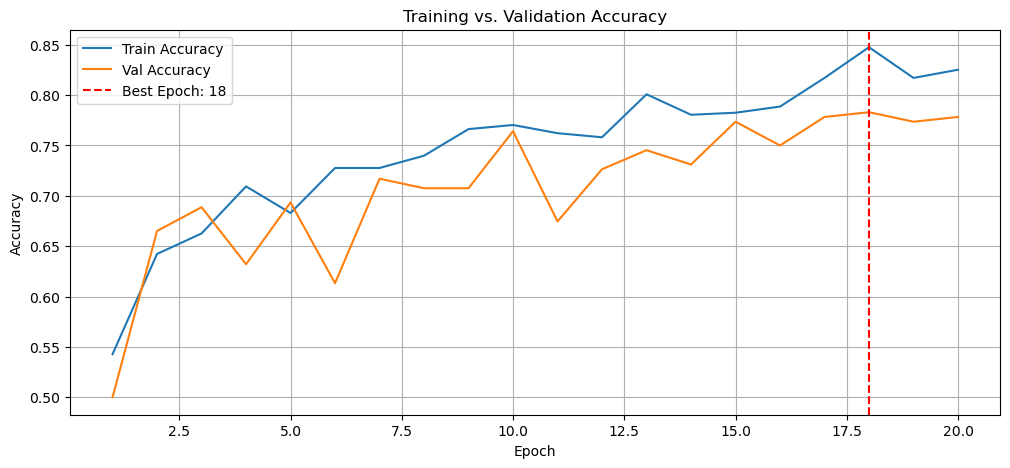

In [91]:
# generate x-axis epoch numbers starting from 1
epochs_range = range(1, len(train_accuracies) + 1)

# --- Loss Plot ---
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy Plot ---
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, [acc / 100 for acc in val_accuracies], label='Val Accuracy')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [94]:
torch.save(model.state_dict(), "deeper_cnn.pth")